# Model Comparison
So sanh 2 model:
- Model 1: XLM-RoBERTa (song ngu)
- Model 2: Hybrid (RoBERTa EN + PhoBERT VI)

Tieu chi: Precision, Recall, F1 tren toan bo va theo tung ngon ngu

In [4]:
!pip install transformers torch scikit-learn sentencepiece langdetect underthesea matplotlib seaborn -q

In [5]:
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from langdetect import detect_langs, DetectorFactory, LangDetectException
from underthesea import word_tokenize
from tqdm import tqdm

DetectorFactory.seed = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MAX_LEN        = 128
BATCH_SIZE     = 32
LANG_THRESHOLD = 0.8

XLM_DIR     = "/kaggle/input/datasets/minhbodoi/xlmroberta-model"
RO_DIR      = "/kaggle/input/datasets/minhbodoi/hybrid-models/roberta"
PH_DIR      = "/kaggle/input/datasets/minhbodoi/hybrid-models/phobert"

Device: cuda


In [6]:
# Load test set
test_en_df = pd.read_csv("/kaggle/input/datasets/minhbodoi/faidset-processed/test_en.csv", encoding="utf-8-sig")
test_vi_df = pd.read_csv("/kaggle/input/datasets/minhbodoi/faidset-processed/test_vi.csv", encoding="utf-8-sig")
test_df = pd.concat([test_en_df, test_vi_df]).reset_index(drop=True)
print(f"Test set: {len(test_df):,} records")
print(test_df.groupby(["language", "label"]).size().to_string())

Test set: 126,179 records
language  label
en        0        60724
          1        62176
vi        0         1959
          1         1320


---
## Phan 1 - Predict voi Model 1 (XLM-RoBERTa)

In [7]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tok    = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len,
                       padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(),
                "attention_mask": enc["attention_mask"].squeeze(),
                "label":          torch.tensor(self.labels[idx], dtype=torch.long)}

tok_xlm   = AutoTokenizer.from_pretrained(XLM_DIR)
model_xlm = AutoModelForSequenceClassification.from_pretrained(XLM_DIR).to(device)
model_xlm.eval()

test_dataset = TextDataset(test_df, tok_xlm, MAX_LEN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

preds_xlm = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="XLM-RoBERTa predicting"):
        out = model_xlm(input_ids=batch["input_ids"].to(device),
                        attention_mask=batch["attention_mask"].to(device))
        preds_xlm.extend(out.logits.argmax(-1).cpu().numpy())

test_df["pred_xlm"] = preds_xlm
print("Model 1 (XLM-RoBERTa) done")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLM-RoBERTa predicting: 100%|██████████| 3944/3944 [16:41<00:00,  3.94it/s]

Model 1 (XLM-RoBERTa) done


---
## Phan 2 - Predict voi Model 2 (Hybrid)

In [8]:
tok_ro   = AutoTokenizer.from_pretrained(RO_DIR)
model_ro = AutoModelForSequenceClassification.from_pretrained(RO_DIR).to(device)
tok_ph   = AutoTokenizer.from_pretrained(PH_DIR)
model_ph = AutoModelForSequenceClassification.from_pretrained(PH_DIR).to(device)
model_ro.eval()
model_ph.eval()

def detect_language(text):
    try:
        results = detect_langs(text[:500])
        top  = results[0]
        lang = top.lang if top.lang in ["en", "vi"] else "other"
        return lang, top.prob
    except LangDetectException:
        return "other", 0.0

def predict_proba(text, model, tokenizer, segment=False):
    if segment:
        text = word_tokenize(text, format="text")
    enc = tokenizer(text, max_length=MAX_LEN, padding="max_length",
                    truncation=True, return_tensors="pt")
    inputs = {"input_ids":      enc["input_ids"].to(device),
              "attention_mask": enc["attention_mask"].to(device)}
    with torch.no_grad():
        logits = model(**inputs).logits
    return F.softmax(logits, dim=-1)[0][1].item()

def hybrid_predict(text):
    lang, lang_prob = detect_language(text)
    if lang_prob >= LANG_THRESHOLD:
        if lang == "en":
            p_ai = predict_proba(text, model_ro, tok_ro)
        elif lang == "vi":
            p_ai = predict_proba(text, model_ph, tok_ph, segment=True)
        else:
            p_ai = (predict_proba(text, model_ro, tok_ro) +
                    predict_proba(text, model_ph, tok_ph, segment=True)) / 2
    else:
        p_ai = (predict_proba(text, model_ro, tok_ro) +
                predict_proba(text, model_ph, tok_ph, segment=True)) / 2
    return 1 if p_ai >= 0.5 else 0

preds_hybrid = [hybrid_predict(t) for t in tqdm(test_df["text"].tolist(), desc="Hybrid predicting")]
test_df["pred_hybrid"] = preds_hybrid
print("Model 2 (Hybrid) done")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hybrid predicting: 100%|██████████| 126179/126179 [26:55<00:00, 78.11it/s]

Model 2 (Hybrid) done


---
## Phan 3 - So sanh ket qua

In [9]:
# Bang so sanh F1 tong hop
results = []
trues   = test_df["label"].tolist()

for model_name, pred_col in [("XLM-RoBERTa", "pred_xlm"), ("Hybrid", "pred_hybrid")]:
    preds = test_df[pred_col].tolist()
    report = classification_report(trues, preds, target_names=["Human", "AI"], output_dict=True)
    for lang in ["overall", "en", "vi"]:
        if lang == "overall":
            sub_true  = trues
            sub_preds = preds
        else:
            sub = test_df[test_df["language"] == lang]
            sub_true  = sub["label"].tolist()
            sub_preds = sub[pred_col].tolist()
        r = classification_report(sub_true, sub_preds, target_names=["Human", "AI"], output_dict=True)
        results.append({
            "Model":     model_name,
            "Language":  lang.upper(),
            "Precision": round(r["macro avg"]["precision"], 4),
            "Recall":    round(r["macro avg"]["recall"],    4),
            "F1":        round(r["macro avg"]["f1-score"],  4),
            "Accuracy":  round(r["accuracy"],               4),
        })

df_results = pd.DataFrame(results)
print("\nBang so sanh 2 model:")
print(df_results.to_string(index=False))


Bang so sanh 2 model:
      Model Language  Precision  Recall     F1  Accuracy
XLM-RoBERTa  OVERALL     0.8010  0.7448 0.7333    0.7461
XLM-RoBERTa       EN     0.7968  0.7372 0.7253    0.7398
XLM-RoBERTa       VI     0.9798  0.9855 0.9824    0.9829
     Hybrid  OVERALL     0.8096  0.7609 0.7521    0.7622
     Hybrid       EN     0.8055  0.7537 0.7446    0.7561
     Hybrid       VI     0.9869  0.9906 0.9886    0.9890


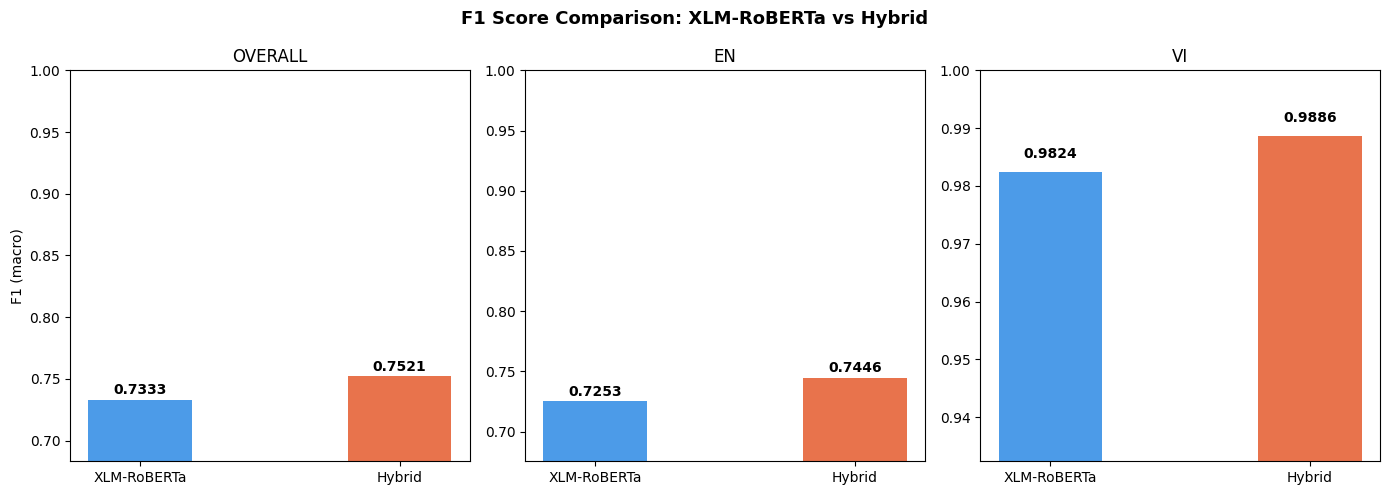

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("F1 Score Comparison: XLM-RoBERTa vs Hybrid", 
             fontsize=13, fontweight="bold")

COLORS = ["#4C9BE8", "#E8734C"]

for i, lang in enumerate(["OVERALL", "EN", "VI"]):
    sub = df_results[df_results["Language"] == lang]
    axes[i].bar(sub["Model"], sub["F1"], color=COLORS, width=0.4)
    axes[i].set_title(lang)
    
    # Tự động tính ylim dựa trên dữ liệu thực
    min_f1 = sub["F1"].min()
    axes[i].set_ylim(max(0, min_f1 - 0.05), 1.0)
    
    axes[i].set_ylabel("F1 (macro)" if i == 0 else "")
    for j, (_, row) in enumerate(sub.iterrows()):
        axes[i].text(j, row["F1"] + 0.002, f"{row['F1']:.4f}",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

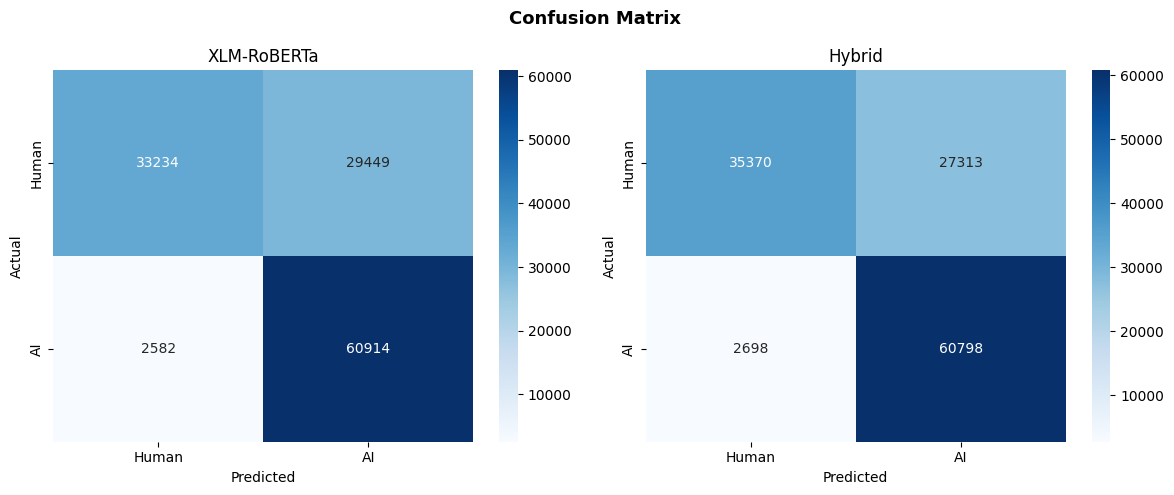

Saved: confusion_matrix.png


In [11]:
# Confusion matrix cho ca 2 model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")

for i, (model_name, pred_col) in enumerate([("XLM-RoBERTa", "pred_xlm"), ("Hybrid", "pred_hybrid")]):
    cm = confusion_matrix(test_df["label"], test_df[pred_col])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Human", "AI"], yticklabels=["Human", "AI"])
    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")